# CVRP Basic Benchmark (X set)

This notebook runs a simple C++ benchmark on **3 small instances** from the **X** set and compares model performance by:
- total distance
- runtime
- percent gap vs best model per instance
- percent gap vs reference solution (when available)


In [1]:
from pathlib import Path
import re
import time
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append("..")
from benchmarking.load_cvrp import load_cvrp_dataset
from models.cpp_bridge import EXECUTABLES, build_cpp_models, run_model
from plot_utils import plot_cvrp_routes

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
# Load set X and pick the 3 smallest instances by DIMENSION
dataset = load_cvrp_dataset(set_names=["X"], verbose=False)

ranked = sorted(
    (
        (instance_id, int(item["problem"].dimension), item)
        for instance_id, item in dataset.items()
    ),
    key=lambda x: (x[1], x[0]),
)

selected = ranked[:3]
selected_instances = {instance_id: item for instance_id, _, item in selected}


def _extract_clusters(instance_id):
    # Instance names are like X/X-n101-k25; clusters = 25
    m = re.search(r"-k(\d+)$", instance_id.split("/")[-1])
    return int(m.group(1)) if m else None


pd.DataFrame(
    [
        {
            "instance_id": instance_id,
            "set": item.get("set_name"),
            "dimensions": dim,
            "clusters": _extract_clusters(instance_id),
            "solution_available": item["solution_path"] is not None,
        }
        for instance_id, dim, item in selected
    ]
)


,instance_id,set,dimensions,clusters,solution_available
0,X/X-n101-k25,X,101,25,True
1,X/X-n106-k14,X,106,14,True
2,X/X-n110-k13,X,110,13,True


In [3]:
# Build C++ binaries (safe to rerun)
build_cpp_models()

PosixPath('/home/manpazito/projects/cvrp-ml-tradeoffs/cpp_models/build')

In [4]:
def parse_reference_cost(solution_path):
    if solution_path is None:
        return None

    path = Path(solution_path)
    if not path.exists():
        return None

    text = path.read_text(encoding="utf-8", errors="ignore")

    patterns = [
        r"\b[Cc]ost\b\s*[:=]?\s*([0-9]+(?:\.[0-9]+)?)",
        r"\b[Oo]pt(?:imal)?\s*[Vv]alue\b\s*[:=]?\s*([0-9]+(?:\.[0-9]+)?)",
        r"\b[Oo]bjective\b\s*[:=]?\s*([0-9]+(?:\.[0-9]+)?)",
    ]

    for pattern in patterns:
        m = re.search(pattern, text)
        if m:
            return float(m.group(1))

    nums = re.findall(r"[0-9]+(?:\.[0-9]+)?", text)
    return float(nums[-1]) if nums else None

In [5]:
# Keep default model behavior but cap heavier models for a quick notebook run
model_options = {
    "constructive": {"method": "nearest_neighbor"},
    "improve_intra": {"max_passes": 2},
    "improve_inter": {"max_passes": 2},
    "tabu": {"max_iterations": 200, "neighborhood_samples": 40, "seed": 42},
    "simulated_annealing": {
        "max_iterations": 300,
        "iterations_per_temperature": 30,
        "seed": 42,
    },
    "iterated_local_search": {"max_iterations": 100, "seed": 42},
    "large_neighborhood_search": {"max_iterations": 100, "seed": 42},
    "genetic": {"generations": 30, "population_size": 24, "seed": 42},
    "memetic": {"generations": 25, "population_size": 24, "seed": 42},
    "ant_colony": {"iterations": 30, "num_ants": 10, "seed": 42},
}


def _project_root():
    cwd = Path.cwd().resolve()
    if (cwd / "models").exists() and (cwd / "cpp_models").exists():
        return cwd
    if (cwd.parent / "models").exists() and (cwd.parent / "cpp_models").exists():
        return cwd.parent
    return cwd


def _file_safe_instance_id(instance_id):
    # Instance IDs are often like "X/X-n101-k25"; keep file names readable
    return instance_id.split("/")[-1]


def _solution_output_path(root_dir, set_name, solver_name, instance_id):
    set_dir = root_dir / "outputs" / set_name
    set_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{solver_name}_{_file_safe_instance_id(instance_id)}.csv"
    return set_dir / filename


def _write_solution_csv(path, instance_id, solver_name, routes):
    rows = []
    for route_id, route in enumerate(routes, start=1):
        for stop_order, node_id in enumerate(route, start=1):
            rows.append(
                {
                    "instance_id": instance_id,
                    "solver_name": solver_name,
                    "route_id": route_id,
                    "stop_order": stop_order,
                    "node_id": int(node_id),
                }
            )

    pd.DataFrame(
        rows,
        columns=["instance_id", "solver_name", "route_id", "stop_order", "node_id"],
    ).to_csv(path, index=False)


reference_cost_by_instance = {
    instance_id: parse_reference_cost(item["solution_path"])
    for instance_id, item in selected_instances.items()
}

project_root = _project_root()
routes_by_key = {}
rows = []
for instance_id, item in selected_instances.items():
    problem = item["problem"]
    set_name = item.get("set_name") or instance_id.split("/")[0] or "unknown"

    for model_key in sorted(EXECUTABLES.keys()):
        opts = model_options.get(model_key, {})
        t0 = time.perf_counter()
        try:
            out = run_model(model_key, problem, **opts)
            elapsed = time.perf_counter() - t0

            best_routes = out.get("best_routes", [])
            routes_by_key[(instance_id, model_key)] = best_routes

            solution_path = _solution_output_path(
                project_root, set_name, model_key, instance_id
            )
            _write_solution_csv(solution_path, instance_id, model_key, best_routes)

            rows.append(
                {
                    "status": "ok",
                    "instance_id": instance_id,
                    "set": set_name,
                    "dimension": int(problem.dimension),
                    "model_name": model_key,
                    "runtime_sec": elapsed,
                    "total_distance": float(out["best_cost"]),
                    "reference_cost": reference_cost_by_instance.get(instance_id),
                    "solution_csv": str(solution_path.relative_to(project_root)),
                }
            )
        except Exception as exc:
            elapsed = time.perf_counter() - t0
            rows.append(
                {
                    "status": "error",
                    "instance_id": instance_id,
                    "set": set_name,
                    "dimension": int(problem.dimension),
                    "model_name": model_key,
                    "runtime_sec": elapsed,
                    "total_distance": None,
                    "reference_cost": reference_cost_by_instance.get(instance_id),
                    "solution_csv": None,
                    "error": f"{type(exc).__name__}: {exc}",
                }
            )

results_df = pd.DataFrame(rows)
print(f"Solution CSVs saved under: {project_root / 'outputs'}")
results_df.head()


Solution CSVs saved under: /home/manpazito/projects/cvrp-ml-tradeoffs/outputs


,status,instance_id,set,dimension,model_name,runtime_sec,total_distance,reference_cost,solution_csv,error
0,ok,X/X-n101-k25,X,101,ant_colony,0.065362,34792.342844,27591.0,outputs/X/ant_colony_X-n101-k25.csv,NaN
1,ok,X/X-n101-k25,X,101,constructive,0.002796,41520.046038,27591.0,outputs/X/constructive_X-n101-k25.csv,NaN
2,ok,X/X-n101-k25,X,101,genetic,0.013798,29991.961081,27591.0,outputs/X/genetic_X-n101-k25.csv,NaN
3,ok,X/X-n101-k25,X,101,improve_inter,0.091779,26634.418329,27591.0,outputs/X/improve_inter_X-n101-k25.csv,NaN
4,ok,X/X-n101-k25,X,101,improve_intra,0.003283,40354.286713,27591.0,outputs/X/improve_intra_X-n101-k25.csv,NaN


In [6]:
ok = results_df[results_df["status"] == "ok"].copy()

best_per_instance = ok.groupby("instance_id", as_index=False)["total_distance"].min()
best_per_instance = best_per_instance.rename(
    columns={"total_distance": "best_total_distance"}
)
ok = ok.merge(best_per_instance, on="instance_id", how="left")

ok["percent_gap_best"] = (
    (ok["total_distance"] - ok["best_total_distance"])
    / ok["best_total_distance"].replace(0, pd.NA)
    * 100.0
).fillna(0.0)

ok["percent_gap_reference"] = (
    (ok["total_distance"] - ok["reference_cost"])
    / ok["reference_cost"].replace(0, pd.NA)
    * 100.0
)
ok.loc[ok["reference_cost"].isna(), "percent_gap_reference"] = pd.NA

attempted = results_df.groupby("model_name").size().rename("attempted_runs")
succeeded = (
    results_df[results_df["status"] == "ok"]
    .groupby("model_name")
    .size()
    .rename("successful_runs")
)

summary_df = ok.groupby("model_name", as_index=False).agg(
    instances=("instance_id", "nunique"),
    mean_distance=("total_distance", "mean"),
    mean_runtime_sec=("runtime_sec", "mean"),
    mean_gap_best=("percent_gap_best", "mean"),
    mean_gap_reference=("percent_gap_reference", "mean"),
)
summary_df = summary_df.merge(attempted, on="model_name", how="left")
summary_df = summary_df.merge(succeeded, on="model_name", how="left")
summary_df["successful_runs"] = summary_df["successful_runs"].fillna(0).astype(int)
summary_df["attempted_runs"] = summary_df["attempted_runs"].fillna(0).astype(int)
summary_df["success_rate"] = (
    summary_df["successful_runs"] / summary_df["attempted_runs"].replace(0, pd.NA)
).fillna(0.0)

summary_df = summary_df.sort_values(
    by=["mean_gap_best", "mean_runtime_sec", "mean_distance"],
    ascending=[True, True, True],
).reset_index(drop=True)

summary_df

,model_name,instances,mean_distance,mean_runtime_sec,mean_gap_best,mean_gap_reference,attempted_runs,successful_runs,success_rate
0,large_neighborhood_search,3,16879.191997,0.497270,4.418980,-22.503901,3,3,1.000000
1,iterated_local_search,3,16879.191997,1.291223,4.418980,-22.503901,3,3,1.000000
2,improve_inter,3,22463.127240,0.080595,35.066106,-3.581051,3,3,1.000000
3,memetic,1,26919.407316,2.306600,39.947287,2.114435,3,1,0.333333
4,genetic,3,24410.199062,0.012619,48.276185,6.170332,3,3,1.000000
5,tabu,3,26504.054208,0.061653,61.747641,16.001482,3,3,1.000000
6,ant_colony,3,27664.085332,0.058827,69.320099,21.546285,3,3,1.000000
7,improve_intra,3,29168.572998,0.004083,78.384416,26.459116,3,3,1.000000
8,simulated_annealing,3,29905.694343,0.006703,82.954998,29.670544,3,3,1.000000
9,constructive,3,29906.653064,0.002432,82.959982,29.674181,3,3,1.000000


In [7]:
# Per-instance view
instance_view = ok[
    ["instance_id", "model_name", "total_distance", "runtime_sec", "percent_gap_best"]
]
instance_view = instance_view.set_index(["instance_id", "model_name"])
instance_view = instance_view.sort_values(
    ["instance_id", "percent_gap_best", "runtime_sec"]
)
instance_view

total_distance  runtime_sec  \
instance_id  model_name                                               
X/X-n101-k25 large_neighborhood_search    16441.252625     0.077643   
             iterated_local_search        16441.252625     0.102818   
             improve_inter                26634.418329     0.091779   
             genetic                      29991.961081     0.013798   
             tabu                         33027.394293     0.067506   
             ant_colony                   34792.342844     0.065362   
             improve_intra                40354.286713     0.003283   
             constructive                 41520.046038     0.002796   
             simulated_annealing          41520.046038     0.007750   
X/X-n106-k14 large_neighborhood_search    19235.390571     0.468814   
             iterated_local_search        19235.390571     0.628053   
             memetic                      26919.407316     2.306600   
             genetic                      27373.635602     0.011409   
             improve_inter                27545.236263     0.113746   
             improve_intra                28352.898898     0.004183   
             tabu                         28479.185850     0.058294   
             simulated_annealing          28898.612068     0.006933   
             constructive                 28901.488229     0.002136   
             ant_colony                   28901.488229     0.053197   
X/X-n110-k13 improve_inter                13209.727127     0.036259   
             large_neighborhood_search    14960.932794     0.945354   
             iterated_local_search        14960.932794     3.142797   
             genetic                      15865.000505     0.012649   
             tabu                         18005.582482     0.059158   
             improve_intra                18798.533384     0.004783   
             constructive                 19298.424924     0.002364   
             simulated_annealing          19298.424924     0.005426   
             ant_colony                   19298.424924     0.057920   

                                        percent_gap_best  
instance_id  model_name                                   
X/X-n101-k25 large_neighborhood_search          0.000000  
             iterated_local_search              0.000000  
             improve_inter                     61.997501  
             genetic                           82.418954  
             tabu                             100.881253  
             ant_colony                       111.616132  
             improve_intra                    145.445330  
             constructive                     152.535783  
             simulated_annealing              152.535783  
X/X-n106-k14 large_neighborhood_search          0.000000  
             iterated_local_search              0.000000  
             memetic                           39.947287  
             genetic                           42.308707  
             improve_inter                     43.200816  
             improve_intra                     47.399653  
             tabu                              48.056187  
             simulated_annealing               50.236679  
             constructive                      50.251632  
             ant_colony                        50.251632  
X/X-n110-k13 improve_inter                      0.000000  
             large_neighborhood_search         13.256941  
             iterated_local_search             13.256941  
             genetic                           20.100895  
             tabu                              36.305484  
             improve_intra                     42.308264  
             constructive                      46.092533  
             simulated_annealing               46.092533  
             ant_colony                        46.092533

,instance_id,model_name,total_distance,runtime_sec
0,X/X-n101-k25,large_neighborhood_search,16441.252625,0.077643
1,X/X-n106-k14,large_neighborhood_search,19235.390571,0.468814
2,X/X-n110-k13,improve_inter,13209.727127,0.036259


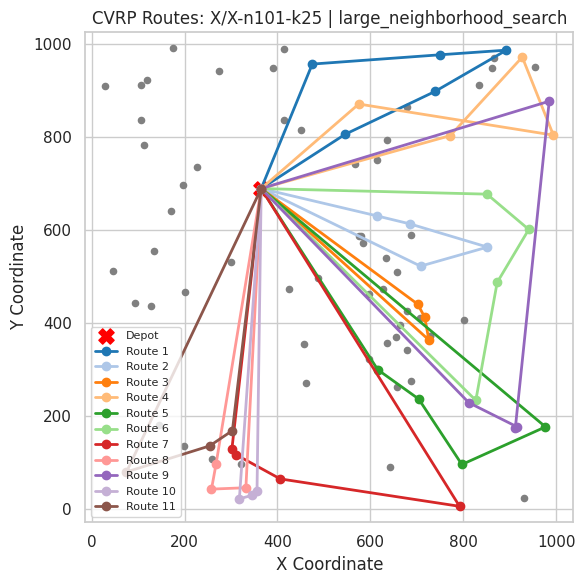

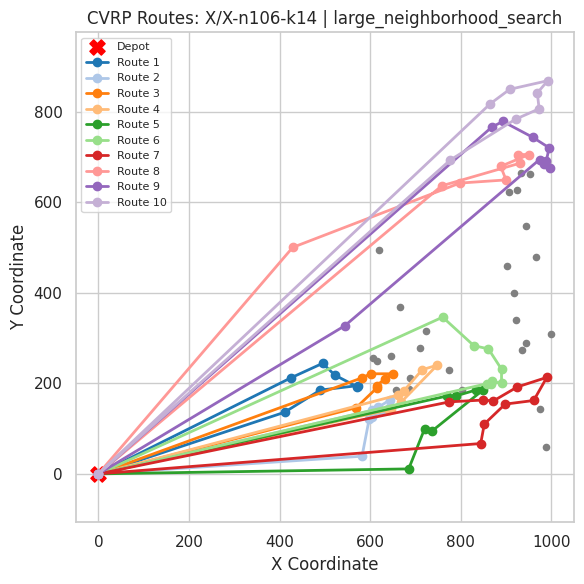

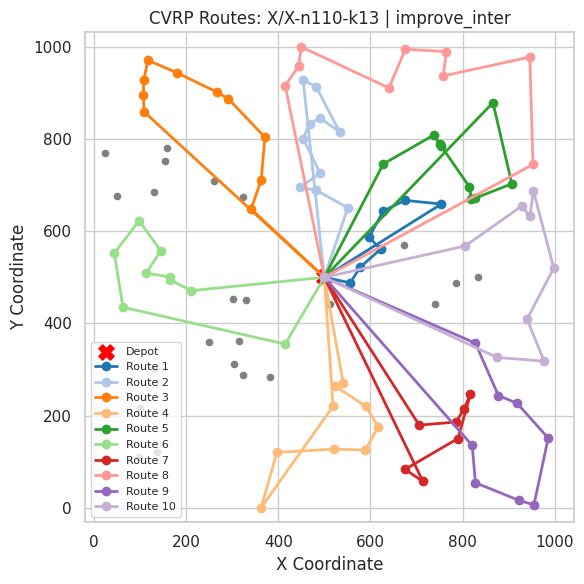

In [8]:
# Plot routes after per-instance view (best model per instance)
from IPython.display import display

best_rows = (
    ok.sort_values(["instance_id", "total_distance", "runtime_sec", "model_name"])
    .groupby("instance_id", as_index=False)
    .first()
)

display(best_rows[["instance_id", "model_name", "total_distance", "runtime_sec"]])

for _, row in best_rows.iterrows():
    instance_id = row["instance_id"]
    model_name = row["model_name"]
    routes = routes_by_key.get((instance_id, model_name))

    if not routes:
        print(f"Skipping {instance_id} ({model_name}): no routes available")
        continue

    plot_cvrp_routes(
        problem=selected_instances[instance_id]["problem"],
        routes=routes,
        instance_id=f"{instance_id} | {model_name}",
    )


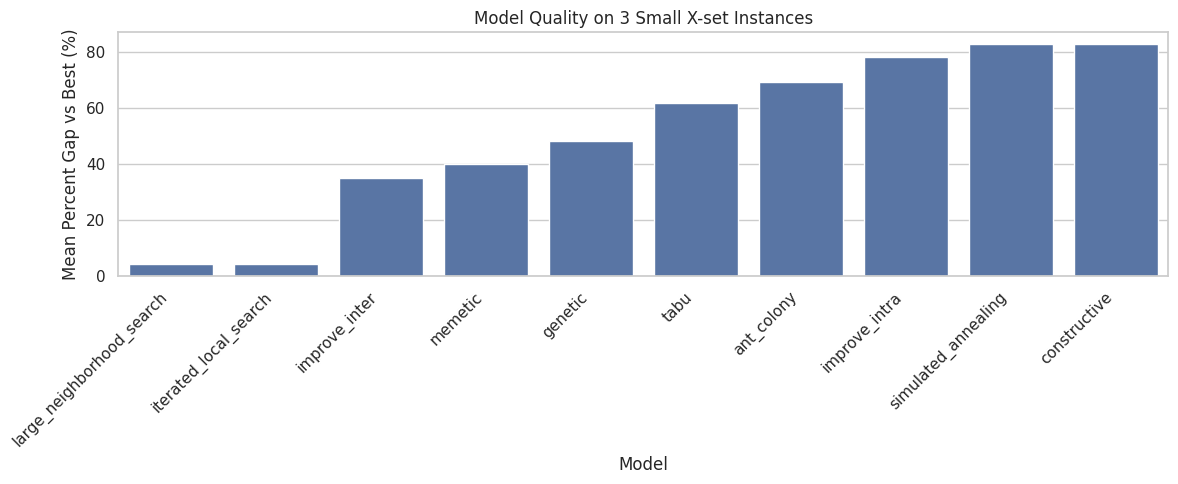

In [9]:
# Plot: mean quality gap vs best
plt.figure(figsize=(12, 5))
sns.barplot(data=summary_df, x="model_name", y="mean_gap_best")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Percent Gap vs Best (%)")
plt.xlabel("Model")
plt.title("Model Quality on 3 Small X-set Instances")
plt.tight_layout()
plt.show()

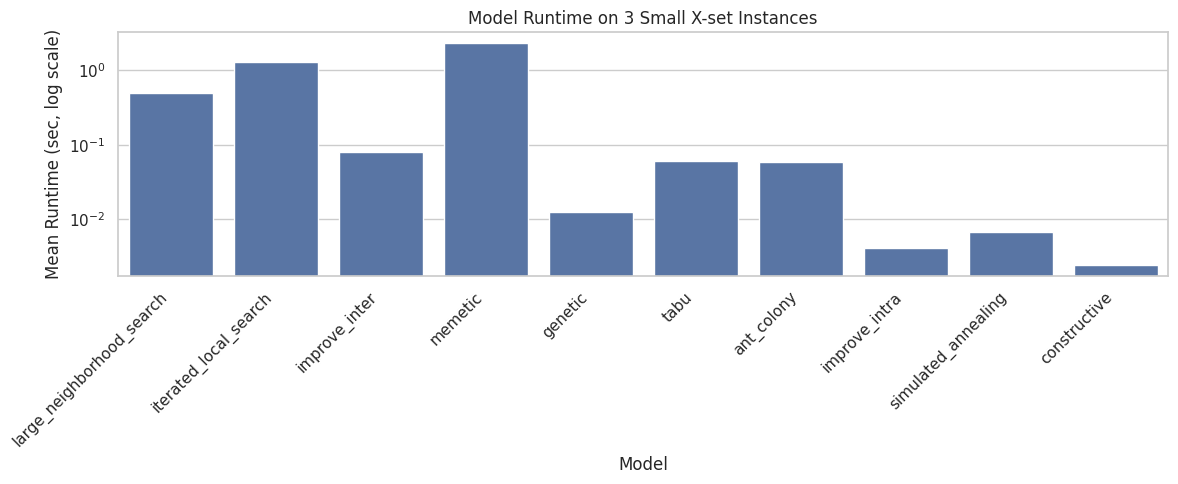

In [10]:
# Plot: mean runtime
plt.figure(figsize=(12, 5))
sns.barplot(data=summary_df, x="model_name", y="mean_runtime_sec")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Runtime (sec, log scale)")
plt.xlabel("Model")
plt.title("Model Runtime on 3 Small X-set Instances")
plt.tight_layout()
plt.show()

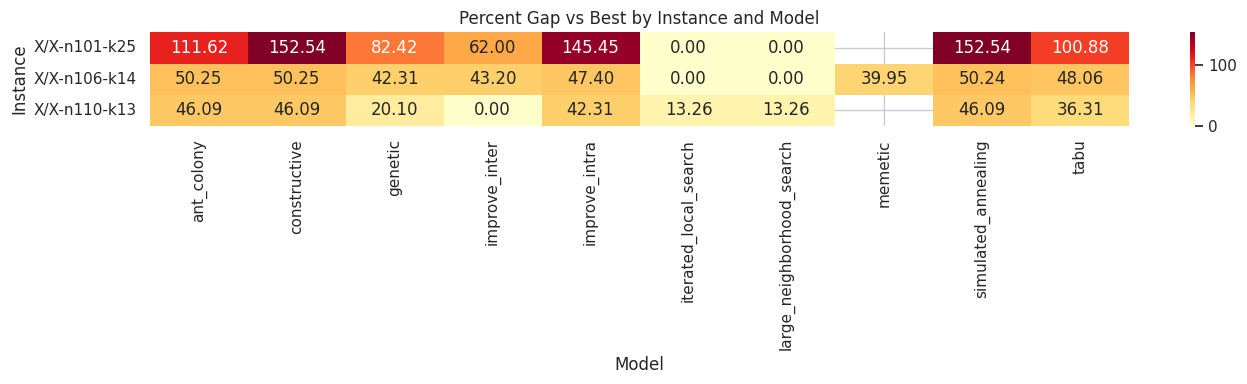

In [11]:
# Heatmap: per-instance percent gap vs best
pivot_gap = ok.pivot_table(
    index="instance_id", columns="model_name", values="percent_gap_best"
)
plt.figure(figsize=(14, 4))
sns.heatmap(pivot_gap, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Percent Gap vs Best by Instance and Model")
plt.xlabel("Model")
plt.ylabel("Instance")
plt.tight_layout()
plt.show()